In [1]:
import pycbc
import copy
import json
import numpy as np
import pycbc.types
from pycbc.types import MultiDetOptionAction
import pycbc.psd
import pycbc.filter
from pycbc.psd.lisa_pre_merger import generate_pre_merger_psds

from pycbc.waveform.pre_merger_waveform import (
    pre_process_data_lisa_pre_merger,
    generate_waveform_lisa_pre_merger,
)

import inpainting_utils
from utils import get_snr_series

from matplotlib import pyplot as plt
plt.style.use('../../paper.mplstyle')

/home/gareth.cabourndavies/environments/env_lisa_premerger/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU response available.
No CuPy or GPU interpolation available.
Could not import fastgb. Please pip install fastgb


## Top level settings

You change some of these things, some might work, some might not.

In [2]:
psdname = 'optimistic'
signumber = '0'
data_length = 2592000
zeroed_length = 2**20 # Data length is not the same for zero-latency vs inpainting as we add extra zeroes to inpainting
sample_rate = 0.2
flen_inpaint = int(zeroed_length) // 2 + 1
delta_f_inpaint = 1 / (2**20 * 5) # Delta_f is not the same for zero-latency vs inpainting as we add extra zeroes to inpainting
delta_t = 1 / sample_rate
time_before = 86400*7


### Zero-latency filter

The following cell computes the SNR using the zero-latency filter approach. This requires code from our premerger paper
https://icg-gravwaves.github.io/lisa_premerger_paper/README.html to run ... Everything else should run off of "standard" installs

This is done to assist making comparison plots later.


In [3]:
## Get the zero-latency SNR series
waveform_params_shared = {
    't_obs_start': data_length, # This is setting the data length.
    'f_lower': 0.000001,
    'low-frequency-cutoff': 0.000001, 
    'f_final': 0.2 / 2,
    'delta_f': 1 / data_length,
    'tdi': '1.5',
    't_offset': 0,
    'cutoff_deltat': 0,
}

data_dict = {
    channel: pycbc.types.timeseries.load_timeseries(
        f'../../datasets/signal_0.hdf',
        group=f"/{channel}",
    )
    for channel in ['LISA_A', 'LISA_E']
}
for data in data_dict.values():
    data._delta_t = 5 # Apparently it is not exactly this in the file, causing issues.

with open('../../datasets/injections.json', 'r') as inj_file:
    injections = json.load(inj_file)

waveform_params = injections['0']
waveform_params.update(waveform_params_shared)

lisa_a_zero_phase_kern = generate_pre_merger_psds(
    psd_file=f'../../datasets/model_AE_TDI1_SMOOTH_optimistic.txt.gz',
    duration=data_length,
    sample_rate=sample_rate,
    kernel_length=17280
)

psds_for_whitening = {
    'LISA_A': lisa_a_zero_phase_kern['FD'],
    'LISA_E': lisa_a_zero_phase_kern['FD']
}

cutoff_time=time_before
search_time=86400
window_length=17280

filter_waveform = copy.deepcopy(waveform_params)
filter_waveform.update({
    'approximant': 'BBHX_PhenomD',
    'mode_array':[(2,2)],
    't_offset': 7365189.431698299,
})

data_dict_pp = pre_process_data_lisa_pre_merger(
        data_dict,
        sample_rate=sample_rate,
        psds_for_whitening=psds_for_whitening,
        window_length=window_length,
        cutoff_time=cutoff_time,
        forward_zeroes=17280,
)
data_f_dict = {}
data_f_dict['LISA_A'] = data_dict_pp['LISA_A'].to_frequencyseries()
data_f_dict['LISA_E'] = data_dict_pp['LISA_E'].to_frequencyseries()

waveforms = generate_waveform_lisa_pre_merger(
    filter_waveform,
    psds_for_whitening,
    sample_rate=sample_rate,
    window_length=window_length,
    cutoff_time=cutoff_time,
    forward_zeroes=17280,
)

snrA = pycbc.filter.matched_filter(
    waveforms['LISA_A'],
    data_f_dict['LISA_A'],
)

snrE = pycbc.filter.matched_filter(
    waveforms['LISA_E'],
    data_f_dict['LISA_E'],
)


/home/gareth.cabourndavies/environments/env_lisa_premerger/lib/python3.10/site-packages/BBHX_Phenom.py:287: RuntimeWarning: Input 'f_lower' is lower than the value calculated from 't_obs_start'.
  warn(err_msg, RuntimeWarning)


## Inpainting

Now let's do the same with inpainting.

In [4]:

# We can just use the PSD directly,
# none of the special loading that was needed before
psd = pycbc.psd.from_txt(
    f'../../datasets/model_AE_TDI1_SMOOTH_optimistic.txt.gz',
    flen_inpaint,
    delta_f_inpaint,
    delta_f_inpaint,
    is_asd_file=False
)


/home/gareth.cabourndavies/environments/env_lisa_premerger/lib/python3.10/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)
/home/gareth.cabourndavies/environments/env_lisa_premerger/lib/python3.10/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


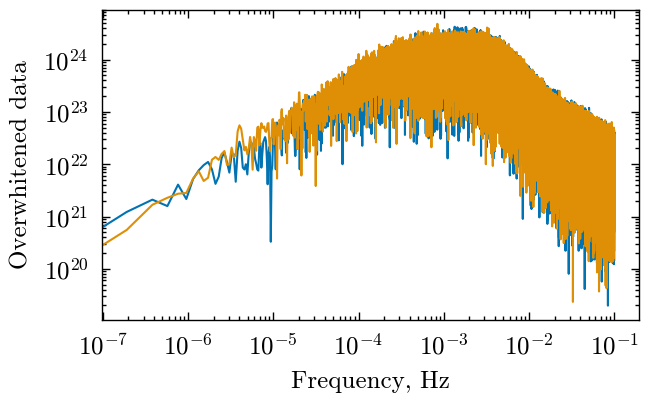

In [5]:
# Get the overwhitened data:

data_dict_resized = copy.deepcopy(data_dict)
for strain in data_dict_resized.values():
    strain.resize(zeroed_length)

data_ow_fd = inpainting_utils.pre_process_data_lisa_pre_merger_inpaint(
    data_dict_resized,
    sample_rate,
    {'LISA_A': psd, 'LISA_E': psd},
    inpaint_start=int((data_length - time_before) * sample_rate),
    inpaint_end=int(data_length*sample_rate) + 10 # 10 samples added for safety at end
)

fig, ax = plt.subplots()
ax.loglog(
    data_ow_fd['LISA_A'].sample_frequencies,
    abs(data_ow_fd['LISA_A'])
)
ax.loglog(
    data_ow_fd['LISA_E'].sample_frequencies,
    abs(data_ow_fd['LISA_E'])
)
ax.set_xlabel('Frequency, Hz')
ax.set_ylabel('Overwhitened data')
fig.show()


/home/gareth.cabourndavies/environments/env_lisa_premerger/lib/python3.10/site-packages/BBHX_Phenom.py:287: RuntimeWarning: Input 'f_lower' is lower than the value calculated from 't_obs_start'.
  warn(err_msg, RuntimeWarning)


True
True


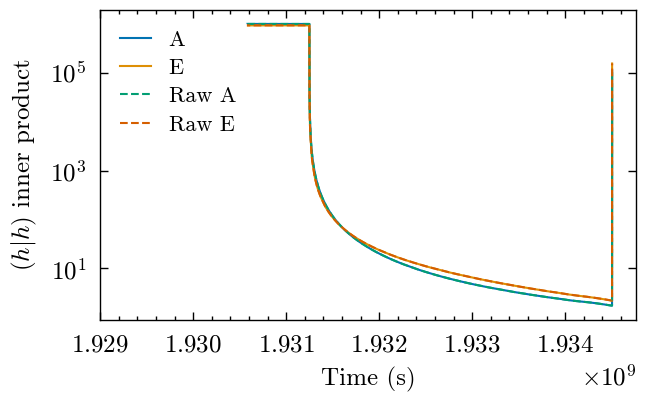

In [6]:
# Changing waveform length now in this bit to match longer length
filter_waveform['t_obs_start'] = int(zeroed_length / sample_rate + 0.5)
filter_waveform['delta_f'] = delta_f_inpaint
filter_waveform['f_final'] = filter_waveform['f_final'] + delta_f_inpaint / 2 # This is a hack to ensure we get the point at f_final returned


# We'll assume the output of this has the merger at the end!
waveforms = inpainting_utils.generate_waveform_lisa_pre_merger_inpaint(
    filter_waveform,
    {'LISA_A': psd, 'LISA_E': psd},
    sample_rate,
) 

hh = {}
# NEW THING: Need time-dependent (h|h).
for channel in waveforms:
    mask = pycbc.types.TimeSeries(
        np.ones(zeroed_length, dtype=data_dict_resized[channel].dtype),
        delta_t=delta_t,
        epoch=data_dict_resized[channel]._epoch
    )
    mask[int((data_length - time_before) * sample_rate):] = 0 # All points after inpaint_start are zeroed in the mask
    # PLEASE NOTE, GAPS WOULD BE ADDED HERE INTO THE MASK
    invpsd = 1./psd # Here is the same for both ifos, but might be different normally
    invpsd[0] = 0 # Don't forget this!!!
    maskfs = mask.to_frequencyseries()
    waveform = (waveforms[channel].to_frequencyseries() * invpsd**0.5).to_timeseries()
    waveform_sq = waveform * waveform
    masked_waveform_sq_fs = maskfs * waveform_sq.to_frequencyseries().conj() 
    masked_waveform_sq_ts = masked_waveform_sq_fs.to_timeseries() # This is what holds (h|h)(t)
    hh[channel] = masked_waveform_sq_ts

# Use the compute_hh_inner_product function so that we know
# that the function is the same as the implementation here
hh_function = inpainting_utils.compute_hh_inner_product(
    filter_waveform,
    {'LISA_A': psd, 'LISA_E': psd},
    sample_rate=sample_rate,
    inpaint_start=int((data_length - time_before) * sample_rate),
    zeroed_length=zeroed_length,
    epoch=data_dict_resized[channel]._epoch,
    gaps=None
)

for channel in hh.keys():
    print(hh_function[channel] == hh[channel])

fig, ax = plt.subplots()
ax.semilogy(hh_function['LISA_A'].sample_times, hh_function['LISA_A'], label='A')
ax.semilogy(hh_function['LISA_E'].sample_times, hh_function['LISA_E'], label='E')
ax.semilogy(hh['LISA_A'].sample_times, hh['LISA_A'], linestyle='--', label='Raw A')
ax.semilogy(hh['LISA_E'].sample_times, hh['LISA_E'], linestyle='--', label='Raw E')
ax.set_xlabel('Time (s)')
ax.set_ylabel('$(h|h)$ inner product')
ax.legend(loc='upper left')
fig.show()

{'mass1': 1000000.0, 'mass2': 1000000.0, 'spin1z': 0, 'spin2z': 0, 'additional_end_data': 1050, 'distance': 27658.011507544677, 'eclipticlongitude': 3.448296944257913, 'eclipticlatitude': 0.44491231446252155, 'inclination': 0.9238365050097769, 'polarization': 3.4236020095353483, 'coa_phase': 2.661901610522322, 'tc': 1931852406.9997194, 'fullband_snr': 1975.4707206749447, 't_obs_start': 5242880, 'f_lower': 1e-06, 'low-frequency-cutoff': 1e-06, 'f_final': 0.10000009536743165, 'delta_f': 1.9073486328125e-07, 'tdi': '1.5', 't_offset': 7365189.431698299, 'cutoff_deltat': 0, 'approximant': 'BBHX_PhenomD', 'mode_array': [(2, 2)]}


/home/gareth.cabourndavies/environments/env_lisa_premerger/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/gareth.cabourndavies/environments/env_lisa_premerger/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


True
True


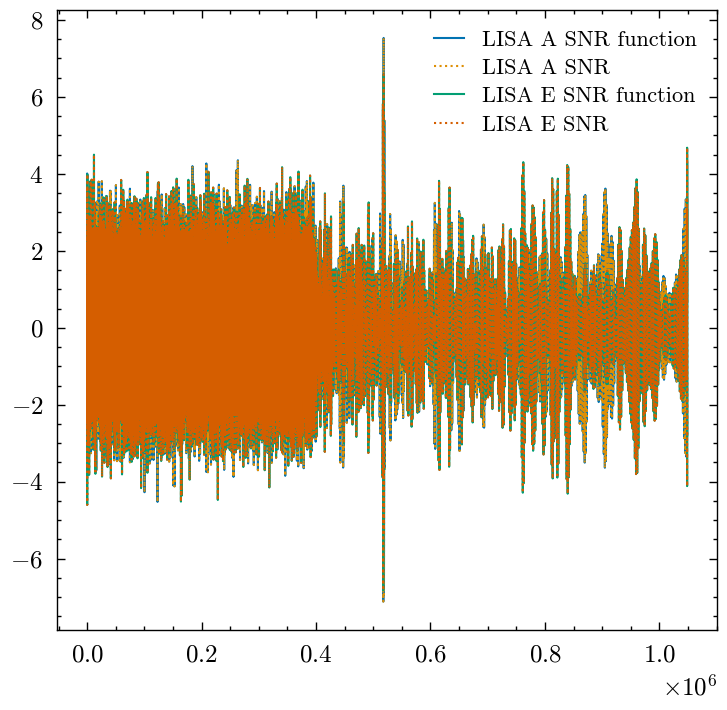

In [7]:
# Now we can matched-filter
snrs = {}
for channel in waveforms:
    snrs[channel] = pycbc.filter.matched_filter(
            waveforms[channel],
            data_ow_fd[channel],
            sigmasq=1,
    ) / (hh_function[channel]**0.5 * 2**0.5) # Not really sure where the factor of 2 comes from, but it is needed

# Use the get_snr_series function so that we know
# that the function is the same as the implementation here
print(filter_waveform)
snrs_function = get_snr_series(
    filter_waveform,
    data_ow_fd,
    psds_for_whitening={'LISA_A': psd, 'LISA_E': psd},
    delta_t=delta_t,
    hh=hh_function,
)

fig, ax = plt.subplots(figsize=(4,4))
ax.plot(snrs_function['LISA_A'], label='LISA A SNR function')
ax.plot(snrs['LISA_A'], linestyle=':', label='LISA A SNR')
ax.plot(snrs_function['LISA_E'], label='LISA E SNR function')
ax.plot(snrs['LISA_E'], linestyle=':', label='LISA E SNR')
ax.legend(loc='upper right')

for channel in ['LISA_A', 'LISA_E']:
    print(snrs_function[channel] == snrs[channel])

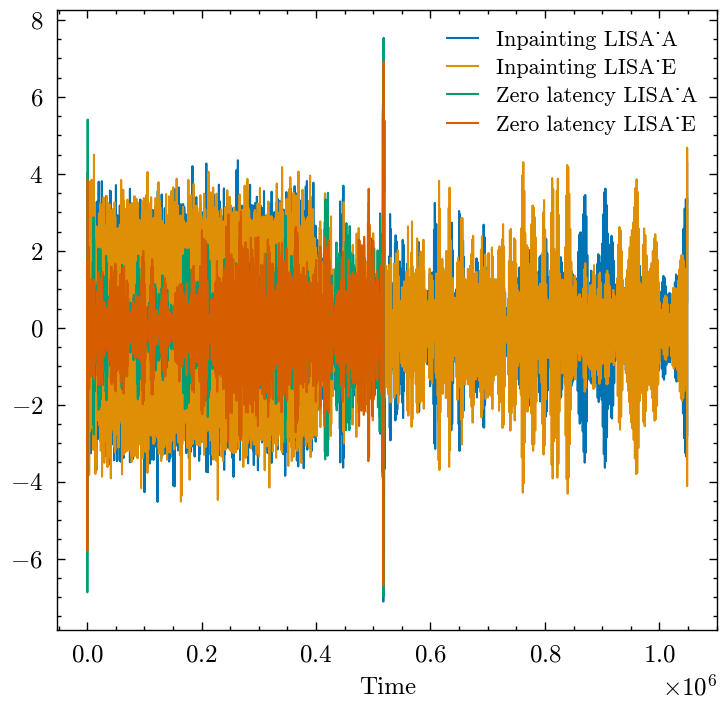

In [8]:
fig, ax = plt.subplots(figsize=(4,4))

for channel in waveforms:
    ax.plot(snrs_function[channel], label=f'Inpainting {channel}')

ax.plot(snrA, label='Zero latency LISA_A')
ax.plot(snrE, label='Zero latency LISA_E')
ax.set_xlabel('Time')
ax.legend(loc='upper right')
fig.show()

# The zero latency filter *should* produce a shorter SNR series than the new method, and should only agree at X-days premerger where
# the cut it.

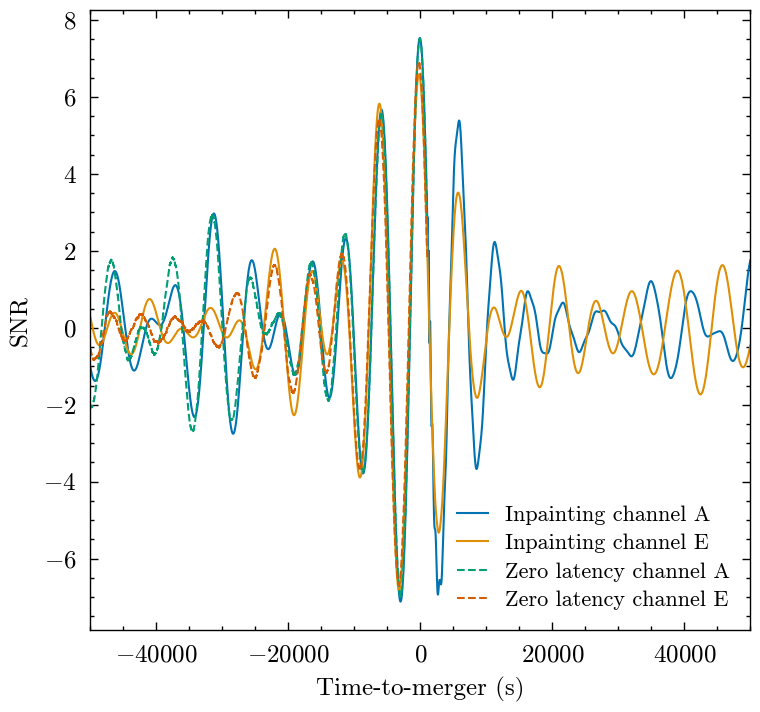

In [9]:
fig2, ax2 = plt.subplots(figsize=(4,4))

for channel in waveforms:
    ax2.plot(
        snrs[channel].sample_times - waveform_params['tc'],
        snrs[channel],
        label=f'Inpainting channel {channel[-1]}'
    )

ax2.plot(
    snrA.sample_times - waveform_params['tc'],
    snrA,
    label='Zero latency channel A',
    linestyle='--',
)
ax2.plot(
    snrE.sample_times - waveform_params['tc'],
    snrE,
    label='Zero latency channel E',
    linestyle='--',
)
ax2.set_xlim([-50000,50000]) # Zoom imn on peak
ax2.legend(loc='lower right')
ax2.set_ylabel('SNR')
ax2.set_xlabel('Time-to-merger (s)')
fig2.show()

# Note this comparison is not as exact as the one in the other notebook
# with zero noise. The noise treatment is not the same so we expect
# some divergence.
